# Attribute Mining Window Sweep — EDA

Loads the output of `run_attribute_mining_window_sweep.py` (one `--output-dir` run) and
produces the stability / discriminativeness / feature-content plots and summary
statistics used to evaluate mined-feature quality for the thesis.

Edit `RUN_DIR` below to point at a different sweep run; everything else is derived from
the tables and CSVs that run wrote out.

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# --- Point this at the sweep run to analyse (relative to this notebook's directory) ---
RUN_DIR = Path(
    "../../../artifacts/experiments/run_attribute_mining_window_sweep/"
    "cscas/20260705_175251_gr3_depth4_gran-0.1-0.2-0.33"
)

FIGURES_DIR = RUN_DIR / "thesis_figures"
FIGURES_DIR.mkdir(exist_ok=True)

assert RUN_DIR.exists(), f"RUN_DIR does not exist: {RUN_DIR}"
print("Analysing:", RUN_DIR.resolve())

Analysing: /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/experiments/run_attribute_mining_window_sweep/cscas/20260705_175251_gr3_depth4_gran-0.1-0.2-0.33


In [2]:
# Fixed categorical colours, assigned once and reused throughout -- never
# re-derived per plot, so the same granularity/leaning always gets the same
# colour across every figure in this notebook.
GRAN_PALETTE = ["#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE", "#AA3377"]
ATTACK_COLOR = "#CC3311"   # warm -> attack-leaning / attack class
BENIGN_COLOR = "#4477AA"   # cool -> benign-leaning / benign class
NEUTRAL_COLOR = "#BBBBBB"


def gran_color_map(grans: list[float]) -> dict[float, str]:
    return {g: GRAN_PALETTE[i % len(GRAN_PALETTE)] for i, g in enumerate(sorted(grans))}


def savefig(fig: plt.Figure, name: str) -> None:
    """Save a 300dpi copy for the thesis alongside the inline notebook display."""
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  saved {path}")


def strip_axes(ax) -> None:
    ax.grid(axis="y", alpha=0.25)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)


def parse_win_start(win_range: str) -> float:
    """'30%\u201340%' -> 0.30 (also tolerates a plain '-' separator).

    Used as a shared, granularity-independent x-axis: a window's raw index
    means different things at different granularities (window 3 covers
    30-40% at gran=0.1 but doesn't exist at gran=0.33), so overlaying
    multiple granularities on the same chart requires aligning on actual
    position in the timeline instead.
    """
    first = re.split(r"[\u2013-]", str(win_range))[0]
    return float(first.strip().rstrip("%")) / 100.0


def base_feature(token: str) -> str:
    """Strip NOT_/threshold suffix to get the underlying attribute name, e.g.
    'NOT_multi_target' -> 'multi_target',
    'signature_matches_per_day_le_143.7' -> 'signature_matches_per_day'.
    """
    t = token.strip()
    if t.startswith("NOT_"):
        t = t[4:]
    m = re.match(r"^(.*)_(le|gt)_[-0-9.eE]+$", t)
    return m.group(1) if m else t

In [3]:
t1 = pd.read_csv(RUN_DIR / "table1_stability.csv")
t2 = pd.read_csv(RUN_DIR / "table2_convergence.csv")
t3 = pd.read_csv(RUN_DIR / "table3_contrast_drop_diagnosis.csv")
t4 = pd.read_csv(RUN_DIR / "table4_persistence.csv")
t5 = pd.read_csv(RUN_DIR / "table5_cross_granularity.csv")
t6 = pd.read_csv(RUN_DIR / "table6_rule_drift.csv")

step1_raw = pd.read_csv(RUN_DIR / "mined_features_overview_step1_raw.csv")
step1_survivors = pd.read_csv(RUN_DIR / "mined_features_overview_step1_survivors.csv")
step2_survivors = pd.read_csv(RUN_DIR / "mined_features_overview_step2_survivors.csv")

t1["win_start"] = t1["win_range"].apply(parse_win_start)
t6["win_start"] = t6["win_range"].apply(parse_win_start)

summary_path = RUN_DIR / "summary.txt"
if summary_path.exists():
    print(summary_path.read_text())

GRANS = sorted(t1["gran"].unique())
GRAN_COLORS = gran_color_map(GRANS)
HAS_EVAL_COL = "n_attack_eval" in step2_survivors.columns

print("Granularities:", GRANS)
print(
    "Step1 raw candidates:", len(step1_raw),
    "| Step1 survivors:", len(step1_survivors),
    "| Step2 leaves:", len(step2_survivors),
)
if not HAS_EVAL_COL:
    print(
        "[note] step2_survivors has no n_attack_eval column -- this run predates "
        "the chronological-holdout fix, so precision/confidence numbers below are "
        "resubstitution estimates, not honest generalization estimates."
    )

        Attribute Mining Window Sweep — 20260705_175251
        Scenarios : cscas
        Granularities: 10%, 20%, 33%
        min_attack_coverage=0.05  min_benign_coverage=0.05
        min_growth_rate=3.0  max_depth=4  min_samples_leaf=20
        no_contrast_filter=False  eval_frac=0.3

        Stability (T1): mean Jaccard=0.786, min=0.691 across all consecutive windows
Drop diagnosis (T3): {'growth_rate_too_close_to_1': 21696, 'insufficient_attack_coverage': 6568, 'insufficient_benign_coverage': 2359}
Persistence (T4): max windows-present per (scenario,gran): 10
Rule drift (T6): 18 distinct top rules seen across 18 windows

Granularities: [np.float64(0.1), np.float64(0.2), np.float64(0.33)]
Step1 raw candidates: 36358 | Step1 survivors: 5735 | Step2 leaves: 95


## 1. Stability

How consistent is the mined feature set across time? A high consecutive-window Jaccard
similarity means the same predicates keep surviving as the data moves forward; a low one
signals either noise or a genuine shift in the underlying traffic. All multi-granularity
charts below share an x-axis of **position in the timeline**, not raw window index --
window 3 covers a different span at each granularity, so window index alone isn't
comparable across granularities.

  saved ../../../artifacts/experiments/run_attribute_mining_window_sweep/cscas/20260705_175251_gr3_depth4_gran-0.1-0.2-0.33/thesis_figures/stability_jaccard_trajectory.png


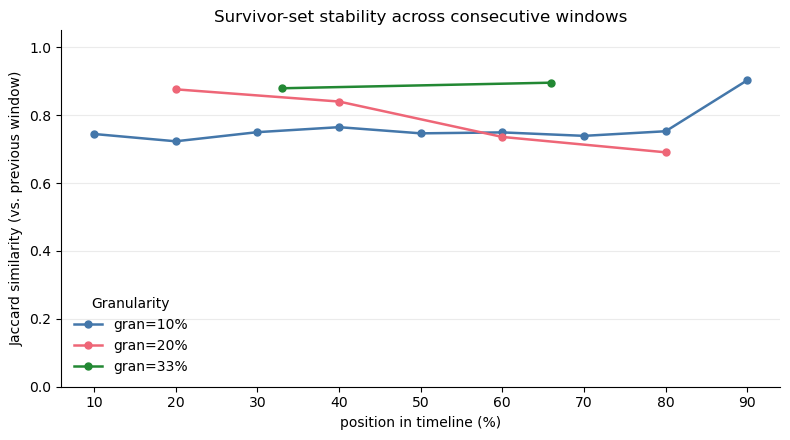

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for g in GRANS:
    sub = t1[(t1["gran"] == g) & t1["jaccard"].notna()].sort_values("win_start")
    ax.plot(
        sub["win_start"] * 100, sub["jaccard"],
        marker="o", markersize=5, linewidth=1.8,
        color=GRAN_COLORS[g], label=f"gran={g:.0%}",
    )
ax.set_xlabel("position in timeline (%)")
ax.set_ylabel("Jaccard similarity (vs. previous window)")
ax.set_ylim(0, 1.05)
ax.set_title("Survivor-set stability across consecutive windows")
ax.legend(title="Granularity", frameon=False)
strip_axes(ax)
fig.tight_layout()
savefig(fig, "stability_jaccard_trajectory.png")
plt.show()

In [5]:
jaccard_summary = (
    t1.dropna(subset=["jaccard"])
    .groupby("gran")["jaccard"]
    .agg(mean="mean", min="min", max="max", n="count")
    .round(4)
)
jaccard_summary.loc["overall"] = [
    round(t1["jaccard"].mean(), 4), round(t1["jaccard"].min(), 4),
    round(t1["jaccard"].max(), 4), t1["jaccard"].notna().sum(),
]
jaccard_summary

,mean,min,max,n
gran,,,,
0.1,0.7637,0.7231,0.9031,9.0
0.2,0.7857,0.6906,0.8762,4.0
0.33,0.8876,0.8793,0.8958,2.0
overall,0.7861,0.6906,0.9031,15.0


### Cross-granularity consistency

Does a feature mined at a coarse granularity also show up in the matching fine
sub-windows covering the same span? A low `frac_in_all` for a given coarse window is a
second, independent signal (alongside a Jaccard dip in the chart above) that something
about the underlying traffic actually changed in that period, rather than the mining
process just being noisy.

  saved ../../../artifacts/experiments/run_attribute_mining_window_sweep/cscas/20260705_175251_gr3_depth4_gran-0.1-0.2-0.33/thesis_figures/stability_cross_granularity.png


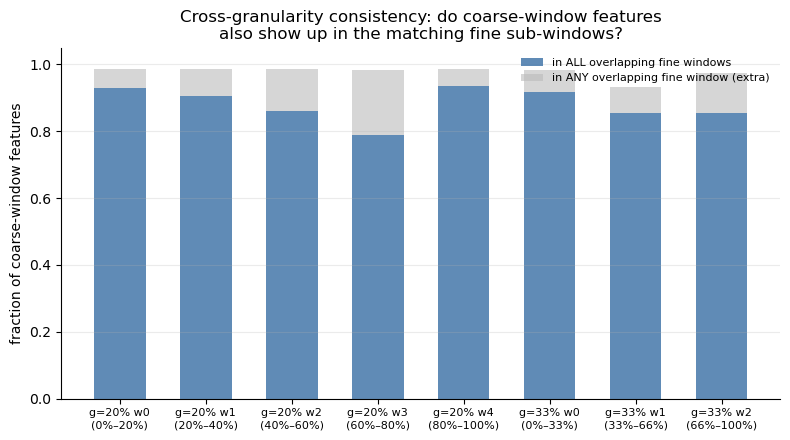

Weakest cross-granularity agreement: gran=20% window 3 (60%–80%), frac_in_all=0.790


In [6]:
if not t5.empty:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(t5))
    labels = [
        f"g={r.coarse_gran:.0%} w{r.coarse_win}\n({r.coarse_range})"
        for r in t5.itertuples()
    ]
    ax.bar(x, t5["frac_in_all"], color=BENIGN_COLOR, alpha=0.85, width=0.6,
           label="in ALL overlapping fine windows")
    ax.bar(x, t5["frac_in_any"] - t5["frac_in_all"], bottom=t5["frac_in_all"],
           color=NEUTRAL_COLOR, alpha=0.6, width=0.6,
           label="in ANY overlapping fine window (extra)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("fraction of coarse-window features")
    ax.set_ylim(0, 1.05)
    ax.set_title(
        "Cross-granularity consistency: do coarse-window features\n"
        "also show up in the matching fine sub-windows?"
    )
    ax.legend(frameon=False, fontsize=8)
    strip_axes(ax)
    fig.tight_layout()
    savefig(fig, "stability_cross_granularity.png")
    plt.show()

    weakest = t5.loc[t5["frac_in_all"].idxmin()]
    print(
        f"Weakest cross-granularity agreement: gran={weakest.coarse_gran:.0%} "
        f"window {weakest.coarse_win} ({weakest.coarse_range}), "
        f"frac_in_all={weakest.frac_in_all:.3f}"
    )
else:
    print("No cross-granularity data (need >=2 granularities in the sweep).")

### Survivor-set size over time

Sanity check alongside the Jaccard trajectory: is the survivor count itself drifting
(e.g. growing steadily, which would inflate churn independent of any real instability),
or just reshuffling around a stable count?

  saved ../../../artifacts/experiments/run_attribute_mining_window_sweep/cscas/20260705_175251_gr3_depth4_gran-0.1-0.2-0.33/thesis_figures/stability_feature_count.png


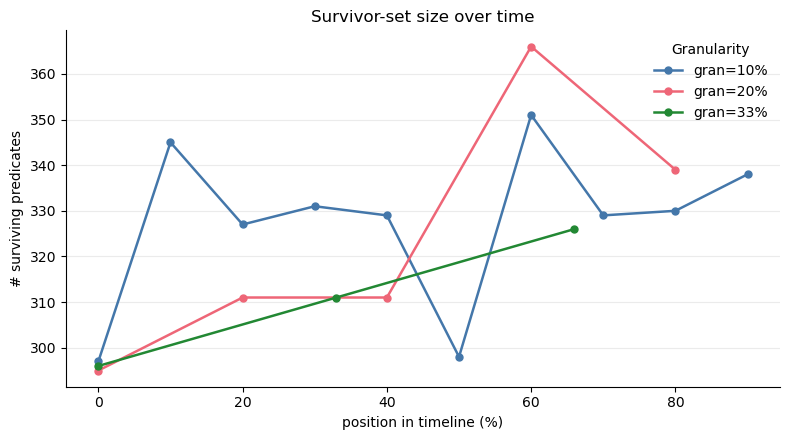

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for g in GRANS:
    sub = t1[t1["gran"] == g].sort_values("win_start")
    ax.plot(
        sub["win_start"] * 100, sub["n_features"],
        marker="o", markersize=5, linewidth=1.8,
        color=GRAN_COLORS[g], label=f"gran={g:.0%}",
    )
ax.set_xlabel("position in timeline (%)")
ax.set_ylabel("# surviving predicates")
ax.set_title("Survivor-set size over time")
ax.legend(title="Granularity", frameon=False)
strip_axes(ax)
fig.tight_layout()
savefig(fig, "stability_feature_count.png")
plt.show()

## 2. Discriminativeness

How good are the mined predicates/rules at actually separating attack from benign --
not just how consistent they are over time.

### Why Step 1 candidates get dropped

`growth_rate_too_close_to_1` dominating is expected and mostly healthy (most candidate
predicates genuinely aren't discriminative); a large `insufficient_*_coverage` share is
worth watching, since it means predicates that *look* discriminative are being rejected
for having too little data behind them.

  saved ../../../artifacts/experiments/run_attribute_mining_window_sweep/cscas/20260705_175251_gr3_depth4_gran-0.1-0.2-0.33/thesis_figures/discriminativeness_drop_reasons.png


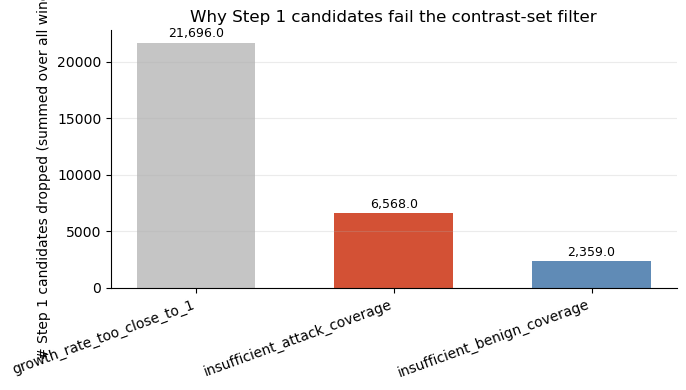

Total dropped: 30,623.0 across 3 granularities / 18 windows


In [8]:
reason_order = [
    "growth_rate_too_close_to_1",
    "insufficient_attack_coverage",
    "insufficient_benign_coverage",
    "other",
]
counts = t3["reason"].value_counts().reindex(reason_order).dropna()
colors = [NEUTRAL_COLOR, ATTACK_COLOR, BENIGN_COLOR, "#DDCC77"][: len(counts)]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(counts))
ax.bar(x, counts.values, color=colors, alpha=0.85, width=0.6)
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.values.max() * 0.01, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("# Step 1 candidates dropped (summed over all windows)")
ax.set_title("Why Step 1 candidates fail the contrast-set filter")
ax.set_xticks(x)
ax.set_xticklabels(counts.index, rotation=20, ha="right")
strip_axes(ax)
fig.tight_layout()
savefig(fig, "discriminativeness_drop_reasons.png")
plt.show()

print(f"Total dropped: {counts.sum():,} across {t1['gran'].nunique()} granularities / {len(t1)} windows")

### Rule drift & holdout confidence

The strongest decision-tree leaf per window, and (if this run used the chronological
holdout) how much held-out attack data backs that confidence estimate -- a window with
few holdout attack examples should be trusted less, even if its confidence number looks
clean.

  saved ../../../artifacts/experiments/run_attribute_mining_window_sweep/cscas/20260705_175251_gr3_depth4_gran-0.1-0.2-0.33/thesis_figures/discriminativeness_rule_drift.png


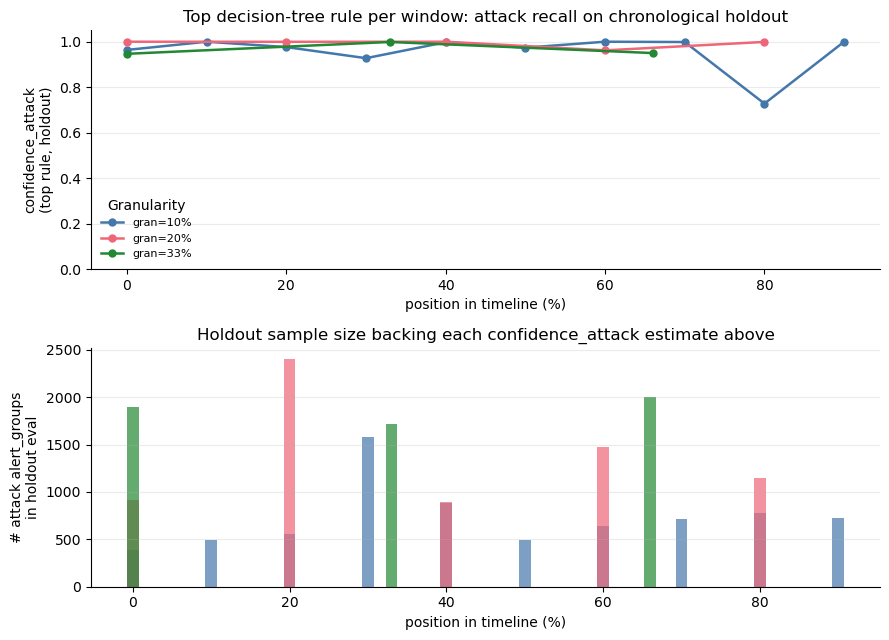

In [9]:
fig, axes = plt.subplots(2 if HAS_EVAL_COL else 1, 1, figsize=(9, 6.5 if HAS_EVAL_COL else 4))
axes = np.atleast_1d(axes)

ax = axes[0]
for g in GRANS:
    sub = t6[(t6["gran"] == g) & t6["confidence_attack"].notna()].sort_values("win_start")
    ax.plot(
        sub["win_start"] * 100, sub["confidence_attack"],
        marker="o", markersize=5, linewidth=1.8,
        color=GRAN_COLORS[g], label=f"gran={g:.0%}",
    )
ax.set_ylabel("confidence_attack\n(top rule" + (", holdout)" if HAS_EVAL_COL else ")"))
ax.set_ylim(0, 1.05)
ax.set_title("Top decision-tree rule per window: attack recall" + (" on chronological holdout" if HAS_EVAL_COL else ""))
ax.legend(title="Granularity", frameon=False, fontsize=8)
ax.set_xlabel("position in timeline (%)")
strip_axes(ax)

if HAS_EVAL_COL:
    ax2 = axes[1]
    for g in GRANS:
        sub = t6[(t6["gran"] == g) & t6["n_attack_eval"].notna()].sort_values("win_start")
        ax2.bar(sub["win_start"] * 100, sub["n_attack_eval"], width=1.5, color=GRAN_COLORS[g], alpha=0.7)
    ax2.set_ylabel("# attack alert_groups\nin holdout eval")
    ax2.set_xlabel("position in timeline (%)")
    ax2.set_title("Holdout sample size backing each confidence_attack estimate above")
    strip_axes(ax2)

fig.tight_layout()
savefig(fig, "discriminativeness_rule_drift.png")
plt.show()

### Precision vs. recall-based "leaning" labels

`confidence_attack`/`confidence_benign` are **recall** (what fraction of all attacks /
all benign this leaf captures), not precision. With a large class imbalance, a leaf can
have `confidence_attack > confidence_benign` (label it "attack-leaning") while still
being *majority benign* in absolute composition -- the box plot below recomputes true
precision `P(class | leaf)` from `confidence_attack` and `n_attack_eval` and compares it
against the naive recall-based label.

  saved ../../../artifacts/experiments/run_attribute_mining_window_sweep/cscas/20260705_175251_gr3_depth4_gran-0.1-0.2-0.33/thesis_figures/discriminativeness_precision_vs_leaning.png


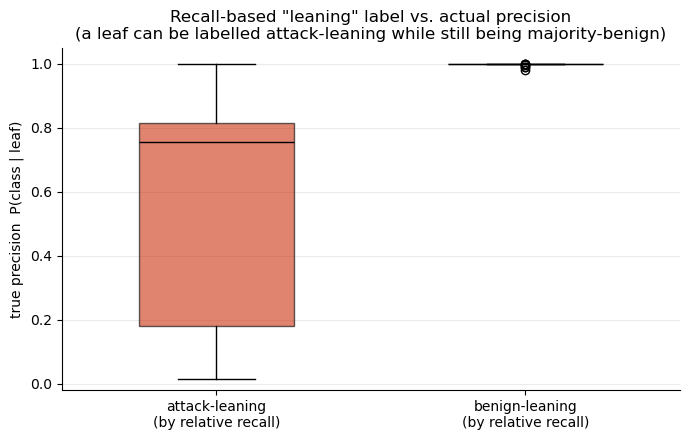

10 of 30 "attack-leaning" leaves are actually majority-benign in true composition (precision < 0.5).


In [10]:
if HAS_EVAL_COL:
    leaves = step2_survivors.copy()
    leaves["n_attack_leaf"] = (leaves["confidence_attack"] * leaves["n_attack_eval"]).round().astype(int)
    leaves["precision_attack"] = leaves["n_attack_leaf"] / leaves["support_count"]
    leaves["precision_benign"] = 1 - leaves["precision_attack"]
    leaves["leaning"] = np.where(
        leaves["confidence_attack"] > leaves["confidence_benign"], "attack-leaning", "benign-leaning"
    )
    leaves["true_precision"] = np.where(
        leaves["leaning"] == "attack-leaning", leaves["precision_attack"], leaves["precision_benign"]
    )

    fig, ax = plt.subplots(figsize=(7, 4.5))
    data = [
        leaves.loc[leaves["leaning"] == "attack-leaning", "true_precision"],
        leaves.loc[leaves["leaning"] == "benign-leaning", "true_precision"],
    ]
    bp = ax.boxplot(
        data,
        tick_labels=["attack-leaning\n(by relative recall)", "benign-leaning\n(by relative recall)"],
        patch_artist=True, widths=0.5, medianprops=dict(color="black"),
    )
    for patch, color in zip(bp["boxes"], [ATTACK_COLOR, BENIGN_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_ylabel("true precision  P(class | leaf)")
    ax.set_ylim(-0.02, 1.05)
    ax.set_title(
        "Recall-based \"leaning\" label vs. actual precision\n"
        "(a leaf can be labelled attack-leaning while still being majority-benign)"
    )
    strip_axes(ax)
    fig.tight_layout()
    savefig(fig, "discriminativeness_precision_vs_leaning.png")
    plt.show()

    n_mislabelled = ((leaves["leaning"] == "attack-leaning") & (leaves["precision_attack"] < 0.5)).sum()
    n_attack_leaning = (leaves["leaning"] == "attack-leaning").sum()
    print(
        f"{n_mislabelled} of {n_attack_leaning} \"attack-leaning\" leaves are actually "
        "majority-benign in true composition (precision < 0.5)."
    )
else:
    print("Skipped: needs n_attack_eval (rerun the sweep with the current code).")

### Support vs. precision

The compactness/quality tradeoff: a small-support, high-precision leaf is the most
valuable kind of workload-reduction candidate (flags very little traffic, and is almost
always right when it does).

  saved ../../../artifacts/experiments/run_attribute_mining_window_sweep/cscas/20260705_175251_gr3_depth4_gran-0.1-0.2-0.33/thesis_figures/discriminativeness_support_vs_precision.png


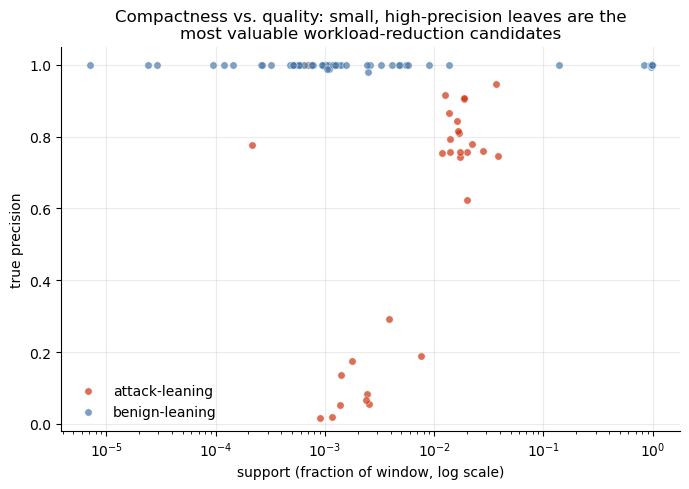

In [11]:
if HAS_EVAL_COL:
    fig, ax = plt.subplots(figsize=(7, 5))
    for label, color in [("attack-leaning", ATTACK_COLOR), ("benign-leaning", BENIGN_COLOR)]:
        sub = leaves[leaves["leaning"] == label]
        ax.scatter(
            sub["support"], sub["true_precision"],
            s=28, alpha=0.7, color=color, label=label,
            edgecolors="white", linewidths=0.4,
        )
    ax.set_xscale("log")
    ax.set_xlabel("support (fraction of window, log scale)")
    ax.set_ylabel("true precision")
    ax.set_ylim(-0.02, 1.05)
    ax.set_title(
        "Compactness vs. quality: small, high-precision leaves are the\n"
        "most valuable workload-reduction candidates"
    )
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    savefig(fig, "discriminativeness_support_vs_precision.png")
    plt.show()

## 3. Feature content

What the mined rules are actually made of: which base features recur, how complex the
rules are, and how the attack/benign split looks per pipeline step.

### Feature reuse

Counts how many decision-tree leaves use each underlying attribute (stripping
thresholds/`NOT_`), across the whole sweep. A handful of features dominating is a sign
the tree keeps rediscovering the same signal rather than a wide variety of independent
patterns.

  saved ../../../artifacts/experiments/run_attribute_mining_window_sweep/cscas/20260705_175251_gr3_depth4_gran-0.1-0.2-0.33/thesis_figures/feature_content_reuse.png


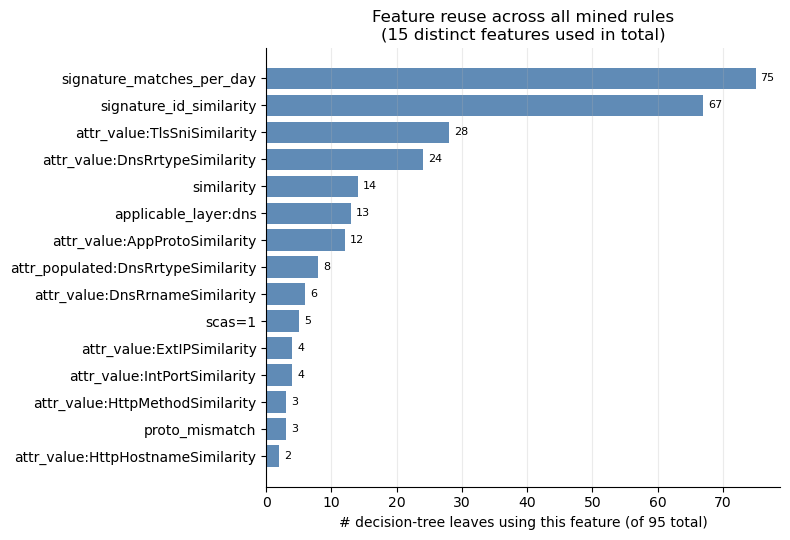

91.6% of all leaves use at least one of the top-2 features (signature_matches_per_day, signature_id_similarity).


In [12]:
feature_counts: dict[str, int] = {}
for pat in step2_survivors["pattern"]:
    for clause in pat.split(" AND "):
        feat = base_feature(clause)
        feature_counts[feat] = feature_counts.get(feat, 0) + 1

reuse = pd.Series(feature_counts).sort_values(ascending=False)
top_n = 15
top = reuse.head(top_n)[::-1]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top.index, top.values, color=BENIGN_COLOR, alpha=0.85)
for i, v in enumerate(top.values):
    ax.text(v + top.values.max() * 0.01, i, str(v), va="center", fontsize=8)
ax.set_xlabel(f"# decision-tree leaves using this feature (of {len(step2_survivors)} total)")
ax.set_title(f"Feature reuse across all mined rules\n({len(reuse)} distinct features used in total)")
ax.grid(axis="x", alpha=0.25)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
savefig(fig, "feature_content_reuse.png")
plt.show()

top2 = list(reuse.index[:2])
top2_leaf_share = step2_survivors["pattern"].apply(
    lambda p: any(base_feature(c) in top2 for c in p.split(" AND "))
).mean()
print(f"{top2_leaf_share:.1%} of all leaves use at least one of the top-2 features ({', '.join(top2)}).")

### Rule complexity (clause length)

Distribution of how many `AND`-clauses each surviving rule has -- bounded above by the
sweep's `--max-depth`, but the redundant-threshold-merge fix means the *effective*
clause count can be lower than the tree's raw split depth.

  saved ../../../artifacts/experiments/run_attribute_mining_window_sweep/cscas/20260705_175251_gr3_depth4_gran-0.1-0.2-0.33/thesis_figures/feature_content_rule_complexity.png


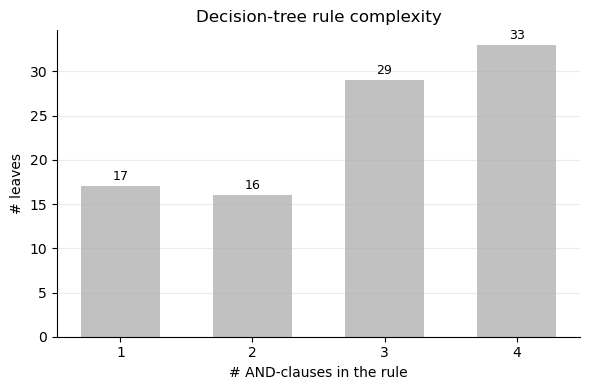

In [13]:
clause_lengths = step2_survivors["pattern"].apply(lambda p: len(p.split(" AND ")))
counts = clause_lengths.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index.astype(str), counts.values, color=NEUTRAL_COLOR, alpha=0.9, width=0.6)
for i, v in enumerate(counts.values):
    ax.text(i, v + counts.values.max() * 0.01, str(v), ha="center", va="bottom", fontsize=9)
ax.set_xlabel("# AND-clauses in the rule")
ax.set_ylabel("# leaves")
ax.set_title("Decision-tree rule complexity")
strip_axes(ax)
fig.tight_layout()
savefig(fig, "feature_content_rule_complexity.png")
plt.show()

### Benign vs. attack leaning ratio, by pipeline step

Step 1 (contrast-set predicates over Suricata signature attributes) and Step 2
(decision-tree leaves) tend to skew in *opposite* directions -- Step 1's categorical
vocabulary is inherently attack-flavoured (rule categories like `cat:EXPLOIT`), while
Step 2's tree structure naturally produces more leaves refining the large benign
majority than isolating the small attack minority. See the precision caveat above before
reading too much into the Step 2 split on its own.

  saved ../../../artifacts/experiments/run_attribute_mining_window_sweep/cscas/20260705_175251_gr3_depth4_gran-0.1-0.2-0.33/thesis_figures/feature_content_benign_attack_ratio.png


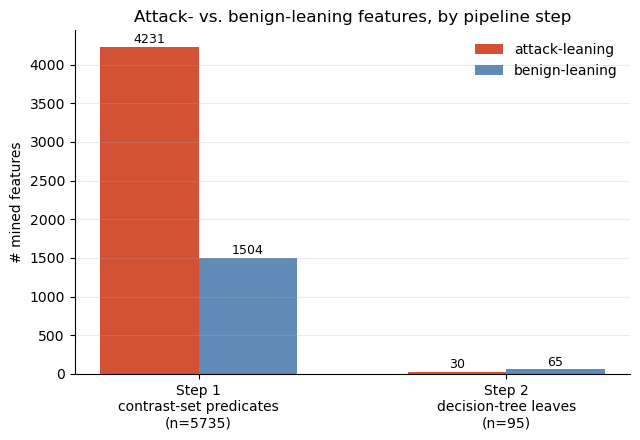

Step 1: 4231 attack-leaning (73.8%) vs 1504 benign-leaning (26.2%)
Step 2: 30 attack-leaning (31.6%) vs 65 benign-leaning (68.4%)


In [14]:
min_growth_rate = 3.0  # must match the sweep's --min-growth-rate for this run
inv = 1.0 / min_growth_rate

s1_attack = int((step1_survivors["growth_rate"] >= min_growth_rate).sum())
s1_benign = int(
    ((step1_survivors["confidence_benign"] > 0) & (step1_survivors["growth_rate"] <= inv)).sum()
)
s2_attack = int((step2_survivors["confidence_attack"] > step2_survivors["confidence_benign"]).sum())
s2_benign = int((step2_survivors["confidence_benign"] > step2_survivors["confidence_attack"]).sum())

fig, ax = plt.subplots(figsize=(6.5, 4.5))
x = np.arange(2)
w = 0.32
attack_vals = [s1_attack, s2_attack]
benign_vals = [s1_benign, s2_benign]
ax.bar(x - w / 2, attack_vals, width=w, color=ATTACK_COLOR, alpha=0.85, label="attack-leaning")
ax.bar(x + w / 2, benign_vals, width=w, color=BENIGN_COLOR, alpha=0.85, label="benign-leaning")
y_max = max(attack_vals + benign_vals)
for i, (a, b) in enumerate(zip(attack_vals, benign_vals)):
    ax.text(i - w / 2, a + y_max * 0.01, str(a), ha="center", fontsize=9)
    ax.text(i + w / 2, b + y_max * 0.01, str(b), ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([
    f"Step 1\ncontrast-set predicates\n(n={len(step1_survivors)})",
    f"Step 2\ndecision-tree leaves\n(n={len(step2_survivors)})",
])
ax.set_ylabel("# mined features")
ax.set_title("Attack- vs. benign-leaning features, by pipeline step")
ax.legend(frameon=False)
strip_axes(ax)
fig.tight_layout()
savefig(fig, "feature_content_benign_attack_ratio.png")
plt.show()

print(f"Step 1: {s1_attack} attack-leaning ({s1_attack/(s1_attack+s1_benign):.1%}) vs {s1_benign} benign-leaning ({s1_benign/(s1_attack+s1_benign):.1%})")
print(f"Step 2: {s2_attack} attack-leaning ({s2_attack/(s2_attack+s2_benign):.1%}) vs {s2_benign} benign-leaning ({s2_benign/(s2_attack+s2_benign):.1%})")

### Feature persistence across windows

For each granularity: of all features that ever survived in *any* window, what fraction
persist across *every* window? A high fraction means the survivor set is dominated by a
stable core rather than one-off noise.

  saved ../../../artifacts/experiments/run_attribute_mining_window_sweep/cscas/20260705_175251_gr3_depth4_gran-0.1-0.2-0.33/thesis_figures/feature_content_persistence.png


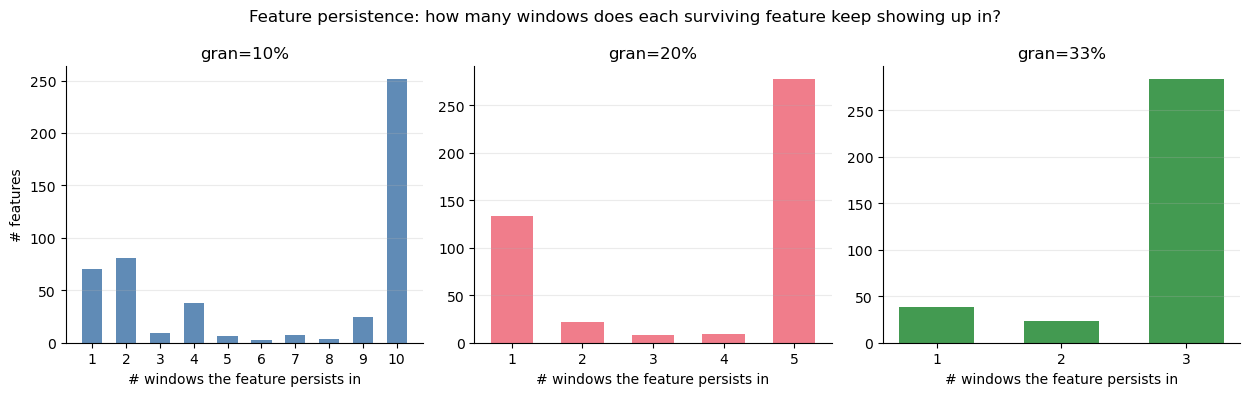

gran=10%: 251/494 (51%) of ever-surviving features persist across every window
gran=20%: 277/449 (62%) of ever-surviving features persist across every window
gran=33%: 283/344 (82%) of ever-surviving features persist across every window


In [15]:
fig, axes = plt.subplots(1, len(GRANS), figsize=(4.2 * len(GRANS), 4), sharey=False)
axes = np.atleast_1d(axes)
for ax, g in zip(axes, GRANS):
    sub = t4[t4["gran"] == g].sort_values("n_windows_present")
    ax.bar(
        sub["n_windows_present"].astype(str), sub["n_features_with_this_persistence"],
        color=GRAN_COLORS[g], alpha=0.85, width=0.6,
    )
    ax.set_title(f"gran={g:.0%}")
    ax.set_xlabel("# windows the feature persists in")
    strip_axes(ax)
axes[0].set_ylabel("# features")
fig.suptitle("Feature persistence: how many windows does each surviving feature keep showing up in?")
fig.tight_layout()
savefig(fig, "feature_content_persistence.png")
plt.show()

for g in GRANS:
    sub = t4[t4["gran"] == g]
    n_total = sub["n_features_with_this_persistence"].sum()
    n_full = sub.loc[
        sub["n_windows_present"] == sub["n_windows_present"].max(), "n_features_with_this_persistence"
    ].sum()
    print(f"gran={g:.0%}: {n_full}/{n_total} ({n_full/n_total:.0%}) of ever-surviving features persist across every window")

## 4. Summary table

Headline numbers for quoting directly in the thesis text. Call `.to_latex()` on any
DataFrame in this notebook (e.g. `jaccard_summary.to_latex()`) to get a pasteable table;
all figures above are also saved as 300dpi PNGs under `RUN_DIR/thesis_figures/`.

In [16]:
summary_rows = {
    "mean consecutive-window Jaccard": round(float(t1["jaccard"].mean()), 4),
    "min consecutive-window Jaccard": round(float(t1["jaccard"].min()), 4),
    "Step 1 raw candidates (total, all windows)": len(step1_raw),
    "Step 1 survivors (total, all windows)": len(step1_survivors),
    "Step 1 survival rate": round(len(step1_survivors) / len(step1_raw), 4) if len(step1_raw) else None,
    "Step 2 leaves (total, all windows)": len(step2_survivors),
    "distinct base features used (Step 2)": len(reuse),
    "top rule mean confidence_attack" + (" (holdout)" if HAS_EVAL_COL else ""): round(float(t6["confidence_attack"].mean()), 4),
    "top rule min confidence_attack" + (" (holdout)" if HAS_EVAL_COL else ""): round(float(t6["confidence_attack"].min()), 4),
}
pd.Series(summary_rows, name="value").to_frame()

,value
mean consecutive-window Jaccard,0.7861
min consecutive-window Jaccard,0.6906
"Step 1 raw candidates (total, all windows)",36358.0000
"Step 1 survivors (total, all windows)",5735.0000
Step 1 survival rate,0.1577
"Step 2 leaves (total, all windows)",95.0000
distinct base features used (Step 2),15.0000
top rule mean confidence_attack (holdout),0.9679
top rule min confidence_attack (holdout),0.7279


## 5. Mining parameter sensitivity

Everything above analyses one fixed run. This section instead asks: how much does each
mining hyperparameter actually matter? It re-runs Steps 1+2 directly (not through the
sweep's CLI) on **one representative window** across a grid of values for each parameter,
holding everything else at this run's own settings (parsed from `summary.txt`).

This is deliberately evaluated on a single window rather than the whole sweep grid --
re-running every `(gran, window)` combination per parameter value would multiply the
already-nontrivial mining cost by the grid size. Results are cached exactly like the
sweep itself (same cache dir, same cache-key logic), so re-running this section after
tweaking a grid only re-mines the new grid points.

In [17]:
# scripts/ has no __init__.py, so it can't be imported as a normal package module --
# load it by file path instead, to reuse its window-loading + single-window mining logic
# (_load_raw_alert_groups, _run_mining_for_window) rather than duplicating it here.
import importlib.util

_sweep_script_path = Path("../scripts/run_attribute_mining_window_sweep.py").resolve()
_spec = importlib.util.spec_from_file_location("run_attribute_mining_window_sweep", _sweep_script_path)
sweep = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(sweep)

# The sweep script pulls in thesis.visualization.mining.common, which calls
# matplotlib.use("Agg") at import time for headless PNG export -- that call is
# global and silently switches this notebook's backend too, breaking inline
# `plt.show()` for every cell below. Switch back to the notebook's own inline
# backend immediately after the import.
%matplotlib inline

print("Loaded mining helpers from", _sweep_script_path)

Loaded mining helpers from /Users/annavisman/stack/TUDelft/thesis/msc-thesis/src/thesis/scripts/run_attribute_mining_window_sweep.py


In [18]:
from thesis.schemas.mining import AttributeMiningConfig

def _parse_summary_params(text: str) -> dict[str, str]:
    return dict(re.findall(r"(\w+)=(\S+)", text))

_summary_text = summary_path.read_text() if summary_path.exists() else ""
_parsed = _parse_summary_params(_summary_text)
_scenarios_match = re.search(r"Scenarios\s*:\s*(\S+)", _summary_text)

# --- Representative window: smallest granularity (fastest to re-mine many times
# over) by default. Override these three if you want a different one. ---
PARAM_SCENARIO = _scenarios_match.group(1).rstrip(",") if _scenarios_match else "cscas"
PARAM_GRAN = min(GRANS)
PARAM_WIN_IDX = 0

_raw_rows = sweep._load_raw_alert_groups(PARAM_SCENARIO)
_n_total = len(_raw_rows)
_win_size = max(1, int(PARAM_GRAN * _n_total))
_n_windows = max(1, _n_total // _win_size)
_start = PARAM_WIN_IDX * _win_size
_end = (PARAM_WIN_IDX + 1) * _win_size if PARAM_WIN_IDX < _n_windows - 1 else _n_total
PARAM_WIN_ROWS = _raw_rows[_start:_end]
print(
    f"Representative window: {PARAM_SCENARIO}, gran={PARAM_GRAN:.0%}, window {PARAM_WIN_IDX} "
    f"({_start/_n_total:.0%}-{_end/_n_total:.0%}, {len(PARAM_WIN_ROWS)} alert_groups)"
)

BASELINE_EVAL_FRAC = float(_parsed.get("eval_frac", 0.3))
BASELINE_NO_CONTRAST_FILTER = _parsed.get("no_contrast_filter", "False") == "True"
PARAM_CACHE_DIR = Path("../../../artifacts/cache/_attribute_window_mining")
PARAM_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def make_config() -> AttributeMiningConfig:
    """This run's own thresholds (from summary.txt) as the sweep baseline;
    each grid below overrides exactly one field off of this."""
    cfg = AttributeMiningConfig()
    cfg.contrast.min_attack_coverage = float(_parsed.get("min_attack_coverage", 0.05))
    cfg.contrast.min_benign_coverage = float(_parsed.get("min_benign_coverage", 0.05))
    cfg.contrast.min_growth_rate = float(_parsed.get("min_growth_rate", 3.0))
    cfg.tree.max_depth = int(_parsed.get("max_depth", 4))
    cfg.tree.min_samples_leaf = int(_parsed.get("min_samples_leaf", 20))
    return cfg


def run_with_config(config: AttributeMiningConfig) -> dict:
    stats_df, survivors_df, leaves_df = sweep._run_mining_for_window(
        win_rows=PARAM_WIN_ROWS,
        scenario=PARAM_SCENARIO,
        gran=PARAM_GRAN,
        win_idx=PARAM_WIN_IDX,
        config=config,
        cache_dir=PARAM_CACHE_DIR,
        no_contrast_filter=BASELINE_NO_CONTRAST_FILTER,
        eval_frac=BASELINE_EVAL_FRAC,
    )
    top = None
    if not leaves_df.empty:
        top = leaves_df.sort_values(["confidence_attack", "support"], ascending=False).iloc[0]
    return {
        "n_raw": len(stats_df),
        "n_survivors": len(survivors_df),
        "n_leaves": len(leaves_df),
        "top_confidence_attack": float(top["confidence_attack"]) if top is not None else np.nan,
        "top_support": float(top["support"]) if top is not None else np.nan,
    }


def sweep_param(section: str, field: str, values: list) -> pd.DataFrame:
    rows = []
    for v in values:
        cfg = make_config()
        setattr(getattr(cfg, section), field, v)
        rows.append({"value": v, **run_with_config(cfg)})
    return pd.DataFrame(rows)

Representative window: cscas, gran=10%, window 0 (0%-10%, 139532 alert_groups)


### Step 1 (contrast-set filter): growth rate & coverage floors

How many predicates survive as the growth-rate and per-class coverage thresholds
tighten? Expect survivor count to fall monotonically as each threshold rises -- a
non-monotonic result would indicate the representative window is too small/noisy for
this analysis.

  saved ../../../artifacts/experiments/run_attribute_mining_window_sweep/cscas/20260705_175251_gr3_depth4_gran-0.1-0.2-0.33/thesis_figures/sensitivity_step1_params.png


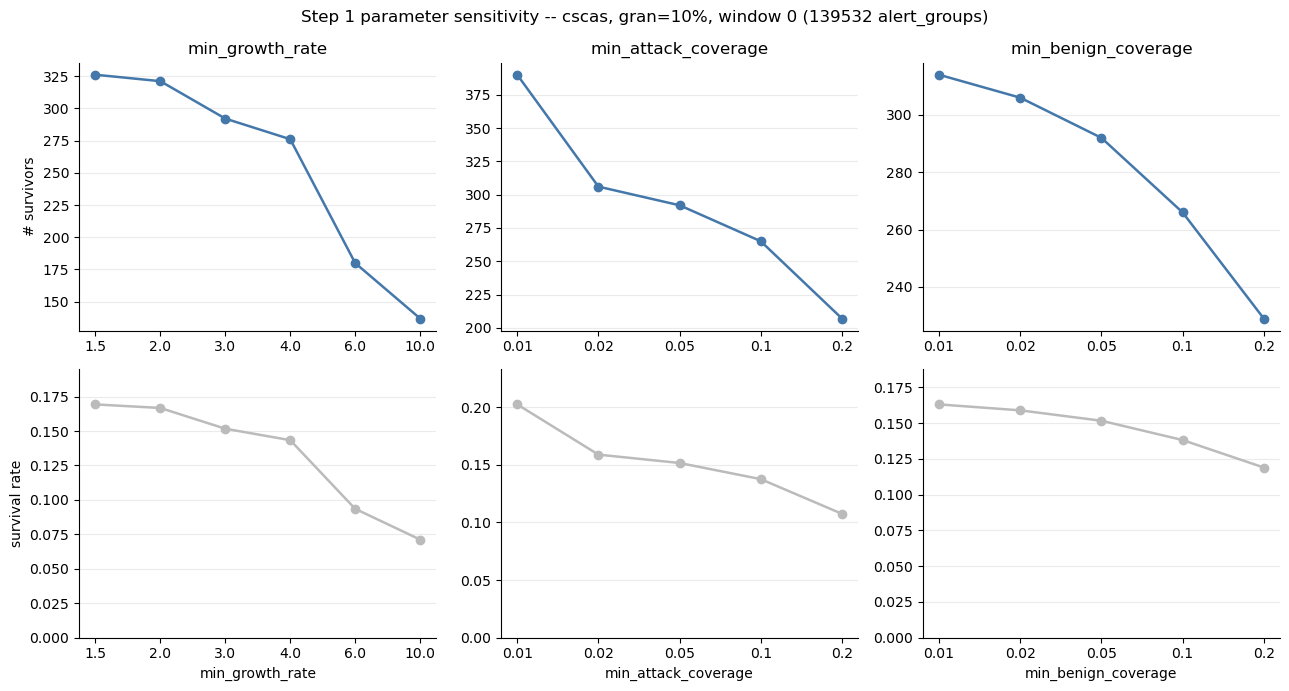

In [19]:
growth_rate_grid = [1.5, 2.0, 3.0, 4.0, 6.0, 10.0]
coverage_grid = [0.01, 0.02, 0.05, 0.1, 0.2]

df_growth_rate = sweep_param("contrast", "min_growth_rate", growth_rate_grid)
df_attack_cov = sweep_param("contrast", "min_attack_coverage", coverage_grid)
df_benign_cov = sweep_param("contrast", "min_benign_coverage", coverage_grid)

step1_grids = [
    ("min_growth_rate", df_growth_rate),
    ("min_attack_coverage", df_attack_cov),
    ("min_benign_coverage", df_benign_cov),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=False)
for col, (name, df) in enumerate(step1_grids):
    x = [str(v) for v in df["value"]]

    ax = axes[0, col]
    ax.plot(x, df["n_survivors"], marker="o", markersize=6, linewidth=1.8, color=BENIGN_COLOR)
    ax.set_title(name)
    ax.set_ylabel("# survivors" if col == 0 else "")
    strip_axes(ax)

    ax2 = axes[1, col]
    survival_rate = df["n_survivors"] / df["n_raw"]
    ax2.plot(x, survival_rate, marker="o", markersize=6, linewidth=1.8, color=NEUTRAL_COLOR)
    ax2.set_xlabel(name)
    ax2.set_ylabel("survival rate" if col == 0 else "")
    ax2.set_ylim(0, max(0.05, survival_rate.max() * 1.15))
    strip_axes(ax2)

fig.suptitle(
    f"Step 1 parameter sensitivity -- {PARAM_SCENARIO}, gran={PARAM_GRAN:.0%}, "
    f"window {PARAM_WIN_IDX} ({len(PARAM_WIN_ROWS)} alert_groups)"
)
fig.tight_layout()
savefig(fig, "sensitivity_step1_params.png")
plt.show()

### Step 2 (decision tree): depth, leaf size, impurity floor

How many leaves does the tree produce, and how strong is its single best rule, as
`max_depth`/`min_samples_leaf`/`min_impurity_decrease` change? `min_impurity_decrease`
at `0.0` reproduces the pre-fix noise-driven splitting behaviour (see the leaf-count
jump at the low end of that column) -- everything from `1e-9` up should look flat, since
real splits reduce impurity by many orders of magnitude more than that.

  saved ../../../artifacts/experiments/run_attribute_mining_window_sweep/cscas/20260705_175251_gr3_depth4_gran-0.1-0.2-0.33/thesis_figures/sensitivity_step2_params.png


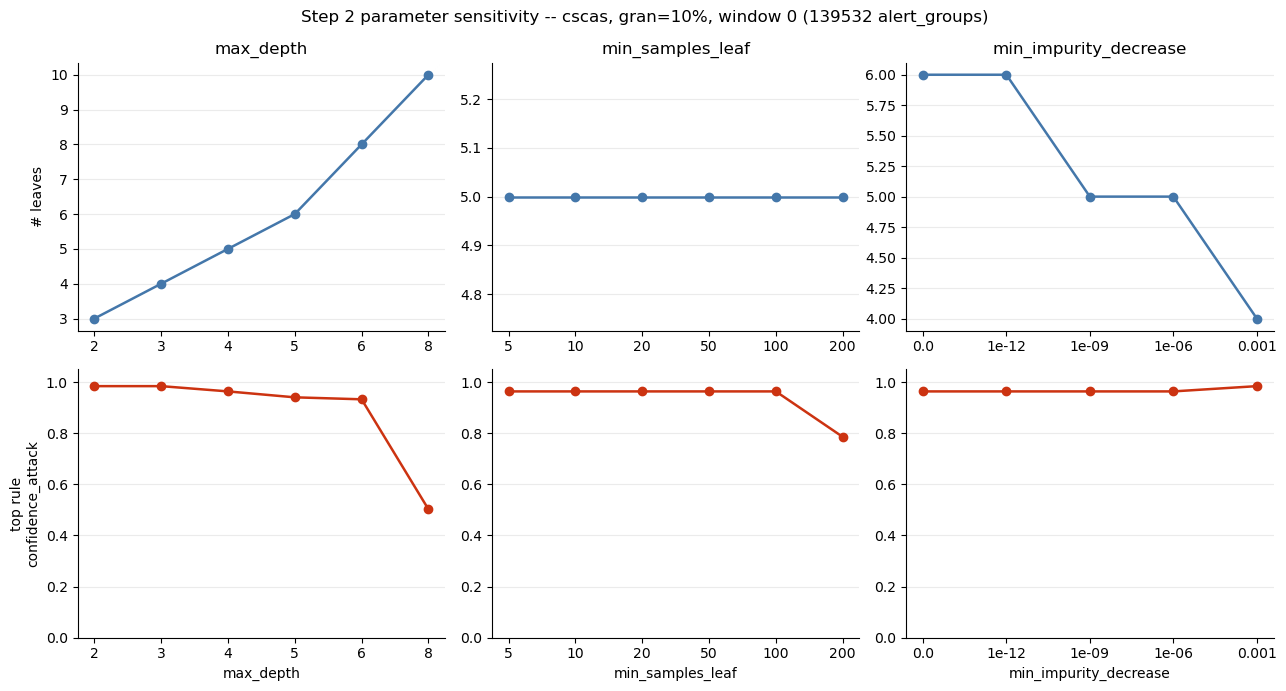

In [20]:
max_depth_grid = [2, 3, 4, 5, 6, 8]
min_samples_leaf_grid = [5, 10, 20, 50, 100, 200]
min_impurity_decrease_grid = [0.0, 1e-12, 1e-9, 1e-6, 1e-3]

df_max_depth = sweep_param("tree", "max_depth", max_depth_grid)
df_min_leaf = sweep_param("tree", "min_samples_leaf", min_samples_leaf_grid)
df_min_impurity = sweep_param("tree", "min_impurity_decrease", min_impurity_decrease_grid)

step2_grids = [
    ("max_depth", df_max_depth),
    ("min_samples_leaf", df_min_leaf),
    ("min_impurity_decrease", df_min_impurity),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=False)
for col, (name, df) in enumerate(step2_grids):
    x = [str(v) for v in df["value"]]

    ax = axes[0, col]
    ax.plot(x, df["n_leaves"], marker="o", markersize=6, linewidth=1.8, color=BENIGN_COLOR)
    ax.set_title(name)
    ax.set_ylabel("# leaves" if col == 0 else "")
    strip_axes(ax)

    ax2 = axes[1, col]
    ax2.plot(x, df["top_confidence_attack"], marker="o", markersize=6, linewidth=1.8, color=ATTACK_COLOR)
    ax2.set_xlabel(name)
    ax2.set_ylabel("top rule\nconfidence_attack" if col == 0 else "")
    ax2.set_ylim(0, 1.05)
    strip_axes(ax2)

fig.suptitle(
    f"Step 2 parameter sensitivity -- {PARAM_SCENARIO}, gran={PARAM_GRAN:.0%}, "
    f"window {PARAM_WIN_IDX} ({len(PARAM_WIN_ROWS)} alert_groups)"
)
fig.tight_layout()
savefig(fig, "sensitivity_step2_params.png")
plt.show()

### Consolidated parameter-sensitivity table

All grid runs above, concatenated -- useful for pulling exact numbers into the thesis
text rather than reading them off the charts.

In [21]:
all_grids = {
    "min_growth_rate": df_growth_rate,
    "min_attack_coverage": df_attack_cov,
    "min_benign_coverage": df_benign_cov,
    "max_depth": df_max_depth,
    "min_samples_leaf": df_min_leaf,
    "min_impurity_decrease": df_min_impurity,
}
param_sensitivity_table = pd.concat(
    {name: df.set_index("value") for name, df in all_grids.items()}, names=["parameter", "value"]
)
param_sensitivity_table

n_raw  n_survivors  n_leaves  top_confidence_attack  top_support
parameter             value                                                                         
min_growth_rate       1.500000e+00   1925          326         5               0.963918     0.011849
                      2.000000e+00   1925          321         5               0.963918     0.011849
                      3.000000e+00   1925          292         5               0.963918     0.011849
                      4.000000e+00   1925          276         5               0.963918     0.011849
                      6.000000e+00   1925          180         5               0.963918     0.011849
                      1.000000e+01   1925          137         5               0.963918     0.011849
min_attack_coverage   1.000000e-02   1925          390         5               0.963918     0.011849
                      2.000000e-02   1925          306         5               0.963918     0.011849
                      5.000000e-02   1925          292         5               0.963918     0.011849
                      1.000000e-01   1925          265         5               0.963918     0.011849
                      2.000000e-01   1925          207         5               0.963918     0.011849
min_benign_coverage   1.000000e-02   1925          314         5               0.963918     0.011849
                      2.000000e-02   1925          306         5               0.963918     0.011849
                      5.000000e-02   1925          292         5               0.963918     0.011849
                      1.000000e-01   1925          266         5               0.963918     0.011849
                      2.000000e-01   1925          229         5               0.963918     0.011849
max_depth             2.000000e+00   1925          292         3               0.984536     0.014357
                      3.000000e+00   1925          292         4               0.984536     0.013258
                      4.000000e+00   1925          292         5               0.963918     0.011849
                      5.000000e+00   1925          292         6               0.940722     0.011371
                      6.000000e+00   1925          292         8               0.932990     0.011228
                      8.000000e+00   1925          292        10               0.502577     0.004658
min_samples_leaf      5.000000e+00   1925          292         5               0.963918     0.011849
                      1.000000e+01   1925          292         5               0.963918     0.011849
                      2.000000e+01   1925          292         5               0.963918     0.011849
                      5.000000e+01   1925          292         5               0.963918     0.011849
                      1.000000e+02   1925          292         5               0.963918     0.011849
                      2.000000e+02   1925          292         5               0.786082     0.009747
min_impurity_decrease 0.000000e+00   1925          292         6               0.963918     0.011849
                      1.000000e-12   1925          292         6               0.963918     0.011849
                      1.000000e-09   1925          292         5               0.963918     0.011849
                      1.000000e-06   1925          292         5               0.963918     0.011849
                      1.000000e-03   1925          292         4               0.984536     0.013258